In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [58]:
df=pd.read_csv('co2_emissions_dirty_dataset.csv')

In [59]:
df.head()

,Emission_ID,Country,Sector,Fuel_Type,CO2_Emissions_MMt,Year,Population_Million,GDP_Billion_USD
0,524.0,Germany,Transport,NaN,84.88993330800491,2001.0,54.447322,525.440177
1,603.0,China,power,Coal,116.75015744966478,2012.0,34.599140,358.814829
2,527.0,India,NaN,Renewables,94.41783050200613,1997.0,67.098282,538.271979
3,32.0,USA,Industry,Coal,80.13243588832287,1995.0,30.037237,659.495345
4,617.0,Germany,Transport,NaN,105.96754905202359,2014.0,40.724356,360.582565


In [60]:
df.shape

(1020, 8)

In [61]:
df.columns

Index(['Emission_ID', 'Country', 'Sector', 'Fuel_Type', 'CO2_Emissions_MMt',
       'Year', 'Population_Million', 'GDP_Billion_USD'],
      dtype='str')

In [62]:
df.dtypes


Emission_ID           float64
Country                   str
Sector                    str
Fuel_Type                 str
CO2_Emissions_MMt         str
Year                  float64
Population_Million    float64
GDP_Billion_USD       float64
dtype: object

In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Emission_ID         1005 non-null   float64
 1   Country             1005 non-null   str    
 2   Sector              838 non-null    str    
 3   Fuel_Type           838 non-null    str    
 4   CO2_Emissions_MMt   1005 non-null   str    
 5   Year                1005 non-null   float64
 6   Population_Million  1005 non-null   float64
 7   GDP_Billion_USD     995 non-null    float64
dtypes: float64(4), str(4)
memory usage: 63.9 KB


In [64]:
df.describe()

,Emission_ID,Year,Population_Million,GDP_Billion_USD
count,1005.000000,1005.000000,1005.000000,995.000000
mean,499.679602,2006.670647,49.951575,530.439782
std,289.435398,9.569310,9.854721,253.642172
min,1.000000,1990.000000,18.121885,129.120339
25%,250.000000,1999.000000,43.647725,431.289807
50%,498.000000,2006.000000,49.847073,501.617180
75%,751.000000,2015.000000,56.874653,566.585718
max,1000.000000,2023.000000,86.577018,2472.743735


In [65]:
df.head()

,Emission_ID,Country,Sector,Fuel_Type,CO2_Emissions_MMt,Year,Population_Million,GDP_Billion_USD
0,524.0,Germany,Transport,NaN,84.88993330800491,2001.0,54.447322,525.440177
1,603.0,China,power,Coal,116.75015744966478,2012.0,34.599140,358.814829
2,527.0,India,NaN,Renewables,94.41783050200613,1997.0,67.098282,538.271979
3,32.0,USA,Industry,Coal,80.13243588832287,1995.0,30.037237,659.495345
4,617.0,Germany,Transport,NaN,105.96754905202359,2014.0,40.724356,360.582565


In [66]:
df.columns

Index(['Emission_ID', 'Country', 'Sector', 'Fuel_Type', 'CO2_Emissions_MMt',
       'Year', 'Population_Million', 'GDP_Billion_USD'],
      dtype='str')

In [67]:
df.isnull().sum()

Emission_ID            15
Country                15
Sector                182
Fuel_Type             182
CO2_Emissions_MMt      15
Year                   15
Population_Million     15
GDP_Billion_USD        25
dtype: int64

In [68]:
df = df.drop("Emission_ID", axis=1)

In [69]:
df.head()

,Country,Sector,Fuel_Type,CO2_Emissions_MMt,Year,Population_Million,GDP_Billion_USD
0,Germany,Transport,NaN,84.88993330800491,2001.0,54.447322,525.440177
1,China,power,Coal,116.75015744966478,2012.0,34.599140,358.814829
2,India,NaN,Renewables,94.41783050200613,1997.0,67.098282,538.271979
3,USA,Industry,Coal,80.13243588832287,1995.0,30.037237,659.495345
4,Germany,Transport,NaN,105.96754905202359,2014.0,40.724356,360.582565


In [70]:
df["Sector"]=df["Sector"].fillna(df["Sector"].mode()[0], inplace=True)
df["Fuel_Type"]=df["Fuel_Type"].fillna(df["Fuel_Type"].mode()[0], inplace=True)

In [71]:
df.head()

,Country,Sector,Fuel_Type,CO2_Emissions_MMt,Year,Population_Million,GDP_Billion_USD
0,Germany,Transport,Renewables,84.88993330800491,2001.0,54.447322,525.440177
1,China,power,Coal,116.75015744966478,2012.0,34.599140,358.814829
2,India,Industry,Renewables,94.41783050200613,1997.0,67.098282,538.271979
3,USA,Industry,Coal,80.13243588832287,1995.0,30.037237,659.495345
4,Germany,Transport,Renewables,105.96754905202359,2014.0,40.724356,360.582565


In [75]:
#convert Unknow to NAN 
#solving co2_Emissions
df["CO2_Emissions_MMt"] = pd.to_numeric(df["CO2_Emissions_MMt"], errors="coerce")
df["CO2_Emissions_MMt"]=df["CO2_Emissions_MMt"].fillna(df["CO2_Emissions_MMt"].median(), inplace=True)


In [79]:
#finding population medain
df["Population_Million"]=df["Population_Million"].fillna(df["Population_Million"].median(), inplace=True)
df["GDP_Billion_USD"]=df["GDP_Billion_USD"].fillna(df["GDP_Billion_USD"].median(), inplace=True)

In [80]:
df.isnull().sum()

Country               15
Sector                 0
Fuel_Type              0
CO2_Emissions_MMt      0
Year                  15
Population_Million     0
GDP_Billion_USD        0
dtype: int64

In [81]:
#convert text into lower case
df["Sector"] = df["Sector"].str.lower()
df["Fuel_Type"] = df["Fuel_Type"].str.lower()
df["Country"] = df["Country"].str.lower()

In [84]:
#duplicate
duplicate=df.duplicated().sum()
print(duplicate)

20


In [87]:
df=df.drop_duplicates()

In [88]:
# checking again duplicate
duplicate=df.duplicated().sum()
print(duplicate)

0


In [89]:
df.info()
df.head()
df.describe()

<class 'pandas.DataFrame'>
Index: 1000 entries, 0 to 1019
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country             985 non-null    str    
 1   Sector              1000 non-null   str    
 2   Fuel_Type           1000 non-null   str    
 3   CO2_Emissions_MMt   1000 non-null   float64
 4   Year                985 non-null    float64
 5   Population_Million  1000 non-null   float64
 6   GDP_Billion_USD     1000 non-null   float64
dtypes: float64(4), str(3)
memory usage: 62.5 KB


,CO2_Emissions_MMt,Year,Population_Million,GDP_Billion_USD
count,1000.000000,985.000000,1000.000000,1000.000000
mean,113.325033,2006.633503,50.060028,528.282358
std,67.880290,9.572716,9.752205,245.262654
min,41.501496,1990.000000,18.121885,129.120339
25%,88.102528,1999.000000,43.832414,433.755521
50%,102.683703,2006.000000,49.847073,501.617180
75%,115.739187,2015.000000,56.854984,565.319677
max,719.909818,2023.000000,86.577018,2472.743735


In [90]:
df.isnull().sum()

Country               15
Sector                 0
Fuel_Type              0
CO2_Emissions_MMt      0
Year                  15
Population_Million     0
GDP_Billion_USD        0
dtype: int64

In [92]:
df["Country"]=df["Country"].fillna(df["Country"].mode()[0], inplace=True)
df["Year"]=df["Year"].fillna(df["Year"].median(), inplace=True)

In [93]:
df.isnull().sum()

Country               0
Sector                0
Fuel_Type             0
CO2_Emissions_MMt     0
Year                  0
Population_Million    0
GDP_Billion_USD       0
dtype: int64

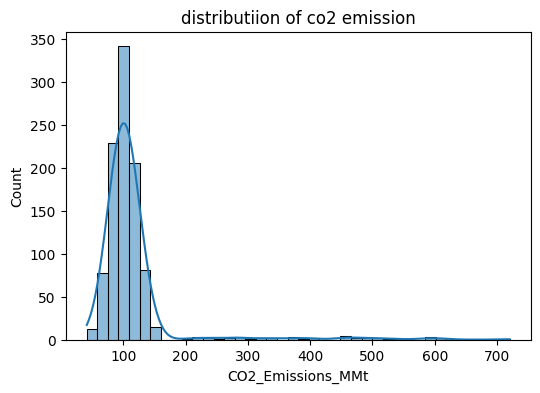

In [96]:
#co2_emission
plt.figure(figsize=(6,4))
sns.histplot(df['CO2_Emissions_MMt'],kde=True,bins=40)
plt.title("distributiion of co2 emission")
plt.show()

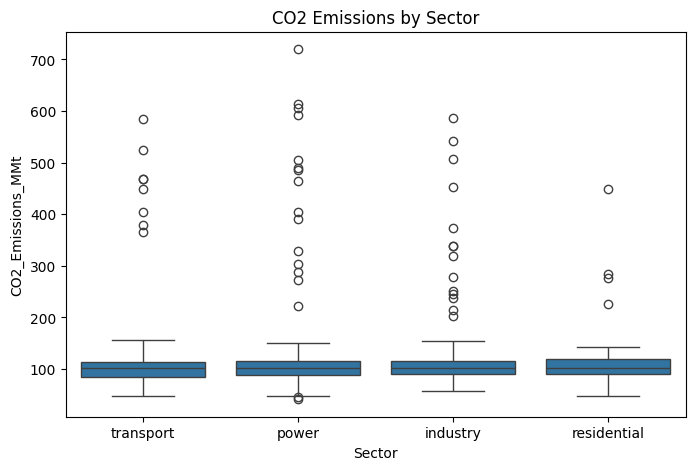

In [97]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Sector", y="CO2_Emissions_MMt", data=df)
plt.title("CO2 Emissions by Sector")
plt.show()


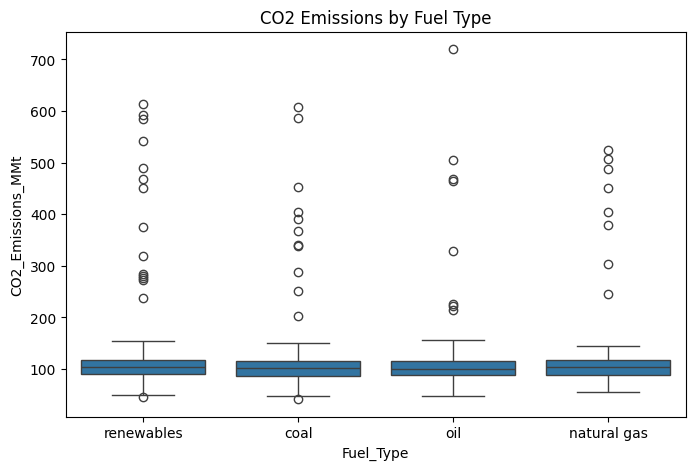

In [101]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Fuel_Type", y="CO2_Emissions_MMt", data=df)
plt.title("CO2 Emissions by Fuel Type")
plt.show()

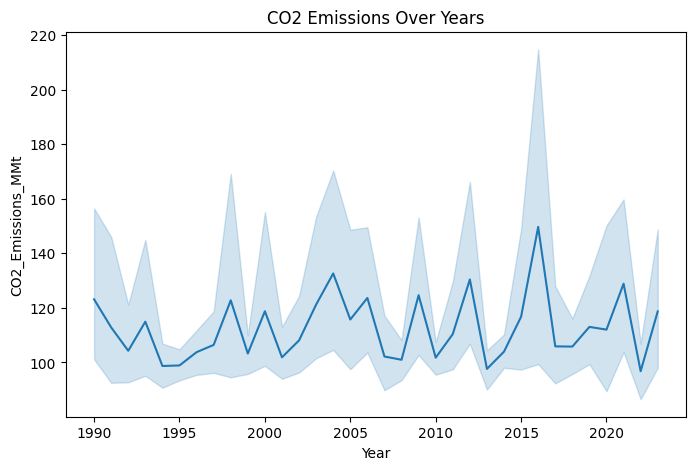

In [102]:
plt.figure(figsize=(8,5))
sns.lineplot(x="Year", y="CO2_Emissions_MMt", data=df)
plt.title("CO2 Emissions Over Years")
plt.show()